In [1]:
%load_ext autoreload
%autoreload 2

# Prova con 400 epoche e training set con 5000 x 3 dati: ottimo risultato sulla funzione semplice

Todo: provare con funzione coi seni, magari espandendo la targetnetwork

In [2]:
import os

# CPU fallback (if GPU is not available)
if 'JAX_PLATFORMS' not in os.environ:
    try:
        from jax import devices
        if not any(d.platform == 'gpu' for d in devices()):
            os.environ['JAX_PLATFORMS'] = 'cpu'
    except Exception:
        os.environ['JAX_PLATFORMS'] = 'cpu'

# Import necessary libraries
import jax.numpy as jnp
import jax.random as random
import optax
from tqdm import tqdm
from data import DataLoader
from models import MLP
from training import train_step, evaluation_step, assign_parameters, EarlyStopping
from utils import variables_generator
from losses import compute_rrmse_alt1
from flax import nnx
from flax.nnx.training.metrics import MultiMetric, Average
import optax
import matplotlib.pyplot as plt

In [3]:
f_to_learn = lambda mu, l, k, x: jnp.exp(l*x) + 0*mu*x + k*x**2

# DATASET GENERATION
key = random.key(0)
mu_domain = (-2, 2)
l_domain = (0, 1)
k_domain = (-2, 2)
x_domain = (-1, 1)
N = 5000
n_realizations = 5
mu, l, k, x = variables_generator(N=N, n_realizations=n_realizations, var_names=['x'], var_domains=[x_domain], hypervar_domains=[mu_domain, l_domain, k_domain], hypervar_names=['mu', 'l', 'k'], key=key).values()
y = f_to_learn(mu, l, k, x)
X = jnp.stack([mu, l, k, x], axis=1)

# DATASET SPLIT AND DATALOADERS CREATION
split_idx = int(N * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
train_dataloader = DataLoader(X_train, y_train, batch_size=1024, shuffle=True)
test_dataloader = DataLoader(X_test, y_test, batch_size=1024, shuffle=False)

In [ ]:
# FOR NOW: TARGET NETWORK WITH KNOWN FIXED NUMBER OF PARAMETERS
targetnetwork = MLP(input_dim=1, output_dim=1, hidden_dims=[8, 8], num_hidden_layers=2, rngs=nnx.Rngs(0), activation_functions=[nnx.tanh, nnx.tanh])
num_params = targetnetwork.num_parameters
hypernetwork = MLP(input_dim=3, output_dim=num_params, hidden_dims=[32, 32, 128], num_hidden_layers=3, rngs=nnx.Rngs(0), activation_functions=[nnx.relu, nnx.relu, nnx.relu])
epochs = 800

# TRAINING AND EVALUATION: DO WE WANT TO PUT THE TRAINING LOOP IN A FUNCTION?
#lr_schedule = optax.linear_schedule(init_value=1e-2, end_value=1e-6, transition_steps=epochs)
lr_schedule = optax.schedules.cosine_decay_schedule(init_value=1e-2, decay_steps=epochs, alpha=1e-6)
# TODO: understand how to use optax.contrib.reduce_on_plateau(), in particular what "accumulation_size" input means
optimizer = nnx.Optimizer(hypernetwork, optax.adam(learning_rate=lr_schedule))

training_metrics = MultiMetric(MSE=Average(argname='loss'), RRMSE=Average(argname='rrmse'))
test_metrics = MultiMetric(MSE=Average(argname='loss'), RRMSE=Average(argname='rrmse'))
training_loss_history = []
test_loss_history = []

# Early stopping setup
#early_stopping = EarlyStopping(patience=30, min_delta=1e-4)

pbar = tqdm(range(epochs))
for epoch in pbar:
    pbar.set_description(f"Epoch {epoch+1}")
    training_metrics.reset()
    test_metrics.reset()
    for data, label in train_dataloader:
        hypervariables = data[:, :-1] # mu, l, k
        x = data[:, -1:] # x
        loss_step = train_step(hypernetwork, targetnetwork, hypervariables, x, label, optimizer, criterion = optax.l2_loss)
        rrmse_step = evaluation_step(hypernetwork, targetnetwork, hypervariables, x, label, criterion = compute_rrmse_alt1)
        training_metrics.update(loss=loss_step.item(), rrmse=rrmse_step.item())
    for data, label in test_dataloader:
        hypervariables = data[:, :-1]
        x = data[:, -1:]
        loss_step = evaluation_step(hypernetwork, targetnetwork, hypervariables, x, label, criterion = optax.l2_loss)
        rrmse_step = evaluation_step(hypernetwork, targetnetwork, hypervariables, x, label, criterion = compute_rrmse_alt1)
        test_metrics.update(loss=loss_step.item(), rrmse=rrmse_step.item())
    step = epoch
    lr_value = lr_schedule(step)
    #early_stopping(test_metrics.compute()['MSE'].item(), hypernetwork, epoch)
    #pbar.set_postfix({"training MSE": training_metrics.compute()['MSE'].item(), "training RRMSE": training_metrics.compute()['RRMSE'].item(), "test MSE": test_metrics.compute()['MSE'].item(), "test RRMSE": test_metrics.compute()['RRMSE'].item(), "learning rate": lr_value, "best epoch": early_stopping.best_epoch + 1})
    pbar.set_postfix({"training MSE": training_metrics.compute()['MSE'].item(), "training RRMSE": training_metrics.compute()['RRMSE'].item(), "test MSE": test_metrics.compute()['MSE'].item(), "test RRMSE": test_metrics.compute()['RRMSE'].item(), "learning rate": lr_value})
    training_loss_history.append(training_metrics.compute()['MSE'].item())
    test_loss_history.append(test_metrics.compute()['MSE'].item())
    # Early stopping check
    # if early_stopping.should_stop:
    #     print(f"Stopping early at epoch {epoch+1}, best epoch was {early_stopping.best_epoch+1}")
    #     break

Epoch 175:  22%|██▏       | 174/800 [01:54<05:27,  1.91it/s, training MSE=0.000195, training RRMSE=0.0158, test MSE=0.000358, test RRMSE=0.0217, learning rate=0.0088898465]

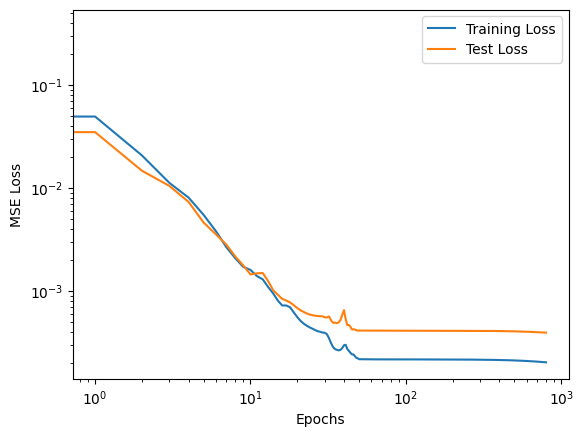

In [12]:
plt.loglog(range(epochs), training_loss_history, label='Training Loss')
plt.loglog(range(epochs), test_loss_history, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [13]:
# PLOTTING RESULTS ON SOME EXAMPLES
N_example = 4
key_example = random.key(1)  # DON'T PUT 0 TO AVOID DATA LEAKAGE
mu_example, l_example, k_example = variables_generator(N = N_example, var_domains = [mu_domain, l_domain, k_domain], key = key_example).values()

example_hypervars = jnp.stack([mu_example, l_example, k_example], axis=1)
particular_hypervars= jnp.array([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
example_hypervars = jnp.vstack([example_hypervars, particular_hypervars]) 

x_vector = jnp.linspace(-1, 1, 101)
x_vector = x_vector[:,None]

In [14]:
plots_data = []

for hypervars in example_hypervars:
    w = hypernetwork(hypervars)  # get the weights from the hypernetwork
    targetnetwork = assign_parameters(targetnetwork, w)  # assign the weights to the target network
    mu, l, k = hypervars 
    y_pred = targetnetwork(x_vector)  # predicted function values
    y_vector = jnp.array([f_to_learn(mu, l, k, x) for x in x_vector])  # true function values
    
    plots_data.append({ #store data for plotting
        'x': x_vector,
        'y_pred': y_pred,
        'y_true': y_vector,
        'params': (mu, l, k)
    })

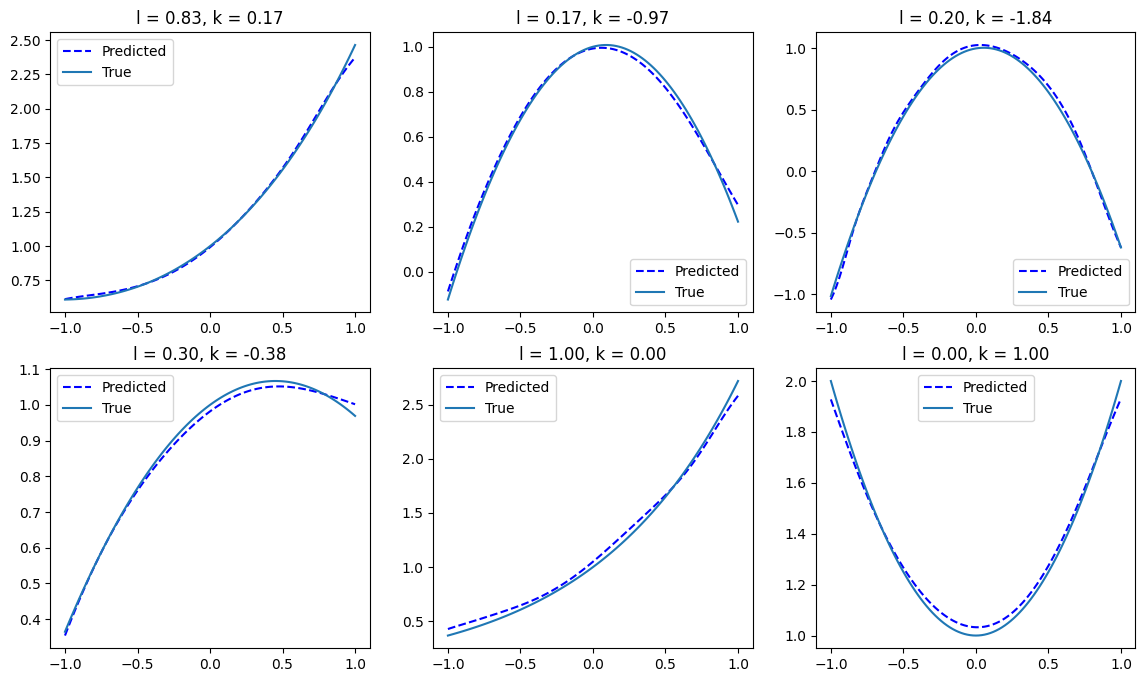

In [15]:
num_cols = 3
fig, ax = plt.subplots(2,num_cols, figsize=(14, 8))
for i, data in enumerate(plots_data[0:6]):
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_pred'], '--b')
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_true'])
    ax[i//num_cols, i%num_cols].legend(['Predicted', 'True'])
    ax[i//num_cols, i%num_cols].set_title(f'l = {data["params"][1]:.2f}, k = {data["params"][2]:.2f}')
plt.show()